# Day2 모델 개발 및 평가

울산 1반 박민규

초기 100회로 전체 수명을 예측하는 회귀 실습입니다. 이 노트북은 고정 실험을 실제 재실행하고 결과를 표시합니다. 외부 시험 점수를 보고 후보·분할·처리를 변경하지 않습니다.

## 1. 환경과 데이터

초기 100사이클까지의 신호로 총 Cycle Life를 예측해, ESS 셀의 열화 위험 선별과 점검 계획에 활용할 가능성을 조사한다. RUL을 직접 예측하는 모델이나 실제 ESS 배포 모델은 아니다.

- 데이터: MIT–Stanford Battery Dataset의 Kaggle version 1 배포본.
- 태스크: **Regression**, y=`cycle_life`(사이클). 분류는 수행하지 않는다.
- 논문·과제의 EOL 정의는 방전 용량이 초기 기준의 80%에 도달하는 시점이다. 이번 정답은 배포본의 `cycle_life`를 사용하며, 모든 라벨의 종료 조건·연속 셀 연결이 동일한지는 별도 감사가 필요하다. 관측 길이로 라벨을 재계산하지 않는다.
- 학습: Batch 1 (2017-05-12), 최종 시험: Batch 2 (2018-02-20).
- 추가 시험: Batch 3 (2018-04-12), 동일한 최종 모델 사용.
- 2018-04-03 extra varcharge 파일은 별도 충전 최적화 실험 데이터이므로 대상 배치에 포함하지 않는다. 이는 셀의 정책 문자열 VarCharge와 구분한다.
- 원시 셀 46/47/46개, 유효 라벨 46/39/44개. 라벨 결측 B2 8개·B3 2개는 평가에서 제외하며 관측 길이로 대체하지 않는다.
- 참가자: **울산 1반 박민규** — EDA, 피처 엔지니어링, 모델 개발, 평가, 문서 작성.


In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
from IPython.display import display, Image

PROJECT = Path.cwd()
if not (PROJECT / 'src/day2_modeling.py').exists():
    PROJECT = PROJECT / 'mini-project'
if not (PROJECT / 'src/day2_modeling.py').exists():
    raise FileNotFoundError('저장소 루트 또는 mini-project 폴더에서 실행하세요.')
sys.path.insert(0, str(PROJECT / 'src'))
import day2_modeling as modeling
import verify_day2
RESULTS = PROJECT / 'results/day2'
cells = modeling.load_cells()
display(cells.groupby('batch').agg(raw_n=('cell_id', 'size'), labeled_n=('cycle_life', 'count')))
print('Python:', sys.version.split()[0])

,raw_n,labeled_n
batch,,
1,46,46
2,47,39
3,46,44


Python: 3.14.7


## 2. Day1에서 사용할 정보를 고르기

| Day1 관측 | Day2 구현 |
| --- | --- |
| B1/B2/B3 수명 중앙값 858.5/472/1,005.5회. B1에는 <500회 셀이 없고 B2에는 28개 | B1 내부 평가와 B2/B3 외부 평가를 구분하고 수명 구간별 오차 분석 |
| Qd 추이는 초기 증가와 이후 감소가 혼재. Knee는 탐색적 근사 | 10~100회 용량 기울기만 후보로 사용하고 전 수명 Knee는 X에서 제외 |
| ΔQ 로그 분산과 수명 Pearson r=-0.886/-0.902/-0.702 | 단일 피처 A 선형회귀를 핵심 기준 후보로 구현 |
| C-rate·온도·충전시간의 관계는 배치별 방향이 다름 | B/C의 추가 가치와 충전시간 평균/중앙값/제외를 동일 B1 CV로 비교 |
| 온도·용량 변화 피처의 강한 중복, 극단 충전시간 기록 | 대표 온도 Tavg, Ridge 규제, QD 변화량 추가/대체 실험 |

상세 그래프와 해석은 [Day1 보고서](DAY1-Design-울산_1반-박민규.md)와 [실행된 EDA 노트북](DAY1-EDA-울산_1반-박민규.ipynb)에 있다. 상관계수는 예측 성능이나 인과효과의 증거가 아니다.

### 수명 분포와 장·단수명 비율

| 배치 | 유효 라벨 n | 수명 범위 / 회 | 중앙값 / 회 | 단수명 <500 | 장수명 >1000 |
| --- | --- | --- | --- | --- | --- |
| B1 | 46 | 534~1227 | 858.5 | 0/46 (0.00%) | 10/46 (21.74%) |
| B2 | 39 | 392~1186 | 472.0 | 28/39 (71.79%) | 3/39 (7.69%) |
| B3 | 44 | 541~1935 | 1005.5 | 0/44 (0.00%) | 23/44 (52.27%) |

동일한 150~2,300회 Histogram으로 비교했다. B1은 500~1,200회대에 분포하고, B2는 사분위 범위 439.5~508.5회에 집중하면서 일부 장수명 셀 때문에 오른쪽 꼬리가 나타난다. B3는 중앙값이 높고 최대 1,935회까지 이어진다. 비율의 분모는 수명 라벨이 유효한 셀이다. B1의 단수명 학습 부족은 B2 과대 예측을 해석하는 근거다.

### 열화 곡선과 Knee 탐색

초기 용량 증가와 이후 감소가 혼재하며, 구간 선형 적합의 후반 기울기 중앙값은 세 배치 모두 전반보다 더 음수여서 후반 가속 열화를 시사한다. B2의 절대 단수명 28셀은 Knee 후보 중앙값 349.5회·후반 기울기 -1.69e-03Ah/회, 장수명 3셀은 914.0회·-6.49e-04Ah/회다. 이 표본에서는 단수명군의 급격한 감소가 더 일찍 나타났지만 작은 장수명군만으로 일반 법칙이나 원인을 확정하지 않는다.

| 배치 | 적합 n | 탐색 기준 충족 n | Knee 후보 중앙값 / 회 |
| --- | --- | --- | --- |
| B1 | 46 | 45 | 599 |
| B2 | 45 | 44 | 353 |
| B3 | 46 | 46 | 827 |

Knee 표는 수명 결측 셀도 포함한 적합 가능 곡선 기준이며, 수명 비율 표와 분모가 다르다. 평활·구간 적합에 의존하는 탐색적 후보이지 화학적 전이의 확정점이 아니다. 전체 수명에서 계산하므로 모델 X에서 제외했다.

### 초기 ΔQ(V)의 장·단수명 차이

B2 단수명군의 ΔQ 전압 평균(셀별 평균의 중앙값)은 -0.0287Ah로 장수명군 -0.0081Ah보다 음의 변화가 크다. 로그 분산 중앙값도 -3.446 대 -4.272로 단수명군이 더 커, 전압에 따른 곡선 변화가 더 크고 덜 평탄한 경향을 요약한다. 분산만으로 모든 전압에서 동일한 형태 차이를 주장하지 않는다.

B1/B3에는 <500회 셀이 없어 절대 장·단수명 비교를 만들지 않았다. 배치 내 Q1 이하/Q3 이상 상대 그룹으로 보완했으며, 세 배치 모두 하위 수명군의 로그 분산 중앙값이 더 컸다.

| 배치 | 하위 수명군 n / 로그 분산 중앙값 | 상위 수명군 n / 로그 분산 중앙값 |
| --- | --- | --- |
| B1 | 12 / -3.577 | 12 / -4.125 |
| B2 | 10 / -3.340 | 10 / -4.232 |
| B3 | 12 / -4.079 | 11 / -4.455 |

### 충전 프로토콜별 평균 수명

배치별 유효 라벨 정책의 최저·최고 평균 예시다. 전체 정책은 `results/policy_stats.csv`에 있다.

| 배치 | 평균 극단 | 정책 | n | 평균 수명 / 회 |
| --- | --- | --- | --- | --- |
| B1 | 최저 | 5.4C(80%)-5.4C | 2 | 546.5 |
| B1 | 최고 | 4C(80%)-4C | 2 | 1226.5 |
| B2 | 최저 | 3.6C(9%)-5C | 2 | 394.5 |
| B2 | 최고 | 5.6C(26%)-4.5C-newstructure | 3 | 991.3 |
| B3 | 최저 | 3.7C(31%)-5.9C-newstructure | 3 | 660.0 |
| B3 | 최고 | 4.8C(80%)-4.8C-newstructure | 6 | 1564.2 |

C1과 수명 상관은 B1 -0.580, B2 +0.191, B3 -0.083으로 고속 충전이 항상 단수명이라는 결론을 지지하지 않는다. 정책별 작은 n, 전환 SOC·온도·측정 조건의 혼재를 고려해야 하며 정책 평균 차이는 인과효과가 아니다. 이를 근거로 정책 변수는 보조 세트 C에서 검증했다.

ΔQ(V)=Q100(V)-Q10(V), 실제 전압 2.0~3.5V의 1,000개 점에서 분산을 계산한다. 주 피처는 `dq_logvar=log10(max(Var(ΔQ), 1e-12))`다. 원본의 사이클 번호 10·100과 전압 축 정렬을 확인한 Day1 파생 파일을 사용한다.

| 세트 | 초기 피처 | 실험 목적 |
| --- | --- | --- |
| A | dq_logvar | 배치 간 방향이 일관된 핵심 신호 |
| B | A + QD_early_slope + Tavg_mean + chargetime_median | 용량·온도·충전시간의 추가 가치 |
| C | B + C1 + switch_pct + C2 | 충전 프로토콜의 추가 가치 |
| B_plus_QDdelta | B + QD100_minus_QD10 | 초기 용량 변화량 추가 |
| B_replace_slope | B의 slope를 QD100_minus_QD10으로 대체 | 중복 피처 대체 |
| B_charge_mean | B의 충전시간 중앙값을 평균으로 대체 | 극단 기록 영향 비교 |
| B_no_charge | B에서 충전시간 제외 | 해당 신호 의존성 확인 |

QD 기울기·온도·충전시간 집계 범위는 10~100회다. 용량은 고정 조건 0<QD<1.5Ah 안에서 기울기를 계산한다. C1·전환%·C2를 해석할 수 없는 VarCharge는 결측으로 두고 학습 fold의 중앙값으로 보완한다. 다른 값은 원본을 보존한다.

`cell_id`, `batch`, `policy`, `cycle_life`, `knee`, `last_QD`, `n_summary`, `n_cycles`, `bad_QD_rows`, `endpoint_quality_flag`는 X에서 제외한다. `policy`는 분할 그룹으로만 사용한다. 코드가 명시적인 초기 피처 허용 목록으로 X를 선택하므로 감사 컬럼이 섞이지 않는다.


In [2]:
display(pd.DataFrame([
    {'set': name, 'features': ', '.join(features)}
    for name, features in modeling.FEATURE_SETS.items()
]))

,set,features
0,A,dq_logvar
1,B,"dq_logvar, QD_early_slope, Tavg_mean, chargeti..."
2,C,"dq_logvar, QD_early_slope, Tavg_mean, chargeti..."
3,B_plus_QDdelta,"dq_logvar, QD_early_slope, Tavg_mean, chargeti..."
4,B_replace_slope,"dq_logvar, QD100_minus_QD10, Tavg_mean, charge..."
5,B_charge_mean,"dq_logvar, QD_early_slope, Tavg_mean, chargeti..."
6,B_no_charge,"dq_logvar, QD_early_slope, Tavg_mean"


## 3. 셀·정책 그룹으로 나누기

1. B1의 23개 정책 그룹에 `GroupShuffleSplit(test_size=0.2, random_state=42)`를 적용한다. 개발 **35셀·18정책**, Hold-out **11셀·5정책**으로 나뉜다. 20%는 정책 수 기준이라 셀 비율은 달라진다.
2. 개발 35셀에서 `GroupKFold(5)`를 적용한다. 같은 셀·정책이 fold 양쪽이나 Hold-out과 겹치지 않는다. fold 검증 n은 8/8/7/6/6이다.
3. 각 fold train에만 median imputer → StandardScaler → 회귀 모델을 fit한다. 원 수명/로그 수명을 같은 fold로 비교하고, 로그 예측은 10의 거듭제곱으로 역변환해 원 사이클 단위에서 평가한다.
4. Dummy 중앙값 1개, A 선형회귀 2개, 여섯 다변수 세트의 Ridge α={0.1,1,10}×타깃 {raw,log10} 36개, **총 39개** 후보를 비교한다.
5. Day1 고정 1-SE 규칙으로 선택한다. 최저 평균 CV MAPE + 해당 후보 fold SD/√5 이내에서 피처 수 → 모델 단순성 → 원 타깃 → 강한 Ridge → CV 오차 순으로 선택한다.
6. 선택을 `model_selection.json`에 저장한 뒤 Hold-out을 확인한다. Hold-out 점수로 다시 선택하지 않는다. 전체 B1 **46셀**로 재학습하고 B2 **39셀**, B3 **44셀**을 평가한다.

분할·후보 목록은 `experiment_manifest.json`, 195개 후보-fold 결과는 `cv_folds.csv`, 모든 OOF 예측은 `cv_all_predictions.csv`에 저장한다. 입력 SHA-256은 `7004beb28b9a1ebc789e00e5da246d27841704b18ef9384867c6406606c8d545`다. 모델은 `final_model.joblib`에 저장한다.

과제상 B2/B3 EDA에서 외부 라벨을 이미 관찰했으므로 완전한 blind test라고 주장하지 않는다. Day2의 선택·전처리 학습에는 외부 평가 점수를 사용하지 않는다. CV는 후보 선택에도 사용했으므로 그 점수는 독립적인 최종 성능 추정치가 아니다. 1-SE는 그룹 fold가 독립이라는 보장이 없는 선택용 근사이며 신뢰구간이 아니다.


In [3]:
b1 = modeling.labeled_batch(cells, 1)
development, holdout, folds = modeling.split_batch1(b1)
display(pd.DataFrame([
    {'split': 'B1 development', 'cells': len(development), 'policies': development.policy.nunique()},
    {'split': 'B1 hold-out', 'cells': len(holdout), 'policies': holdout.policy.nunique()},
]))
display(pd.DataFrame([
    {'fold': i, 'train_n': len(train), 'valid_n': len(valid),
     'policy_overlap': len(set(development.iloc[train].policy) & set(development.iloc[valid].policy))}
    for i, (train, valid) in enumerate(folds, 1)
]))

,split,cells,policies
0,B1 development,35,18
1,B1 hold-out,11,5


,fold,train_n,valid_n,policy_overlap
0,1,27,8,0
1,2,27,8,0
2,3,28,7,0
3,4,29,6,0
4,5,29,6,0


## 4. 고정한 전체 실험 실행

아래 셀에서 CV 선택 → Hold-out → 전체 B1 재학습 → B2/B3 평가를 실행합니다. 전처리와 타깃 변환을 포함한 코드의 원문은 `src/day2_modeling.py`에서 확인할 수 있습니다.

In [4]:
run_result = modeling.run()
verification = verify_day2.verify()

{
  "selected": "A_linear_raw_a0",
  "B1_development": 35,
  "B1_holdout": 11,
  "metrics": {
    "Hold-out B1": {
      "MAPE_pct": 13.143946264257933,
      "MAE_cycles": 123.48541876101154,
      "RMSE_cycles": 151.0292710102405,
      "R2": 0.3622915425877361
    },
    "Test B2": {
      "MAPE_pct": 31.52907097330911,
      "MAE_cycles": 155.58845173936453,
      "RMSE_cycles": 169.5563152442445,
      "R2": 0.4023946567204464
    },
    "Test B3": {
      "MAPE_pct": 12.590543552458486,
      "MAE_cycles": 157.5043303258112,
      "RMSE_cycles": 258.8993735559201,
      "R2": 0.3037784555328853
    },
    "CV pooled OOF": {
      "MAPE_pct": 7.290069661490091,
      "MAE_cycles": 60.527044194043576,
      "RMSE_cycles": 75.47930520100809,
      "R2": 0.8193550800334499
    }
  }
}
{
  "status": "PASS",
  "check_count": 9,
  "checks": [
    "139셀 원본·46/39/44 유효 라벨·입력 해시 확인",
    "Hold-out 및 5개 fold의 셀·정책 중복 없음; OOF 1회씩",
    "39개 후보 및 고정 1-SE 선택 규칙 재검증",
    "외부 라벨·미래 정보 변경에 개발 입력

## 5. 모델 비교와 선택 근거

| 각 세트의 최저 평균 후보 / Dummy | 피처 수 | CV MAPE (%) | fold SD (%) |
| --- | --- | --- | --- |
| A_linear_log10_a0 | 1 | 7.134 | 2.410 |
| B_charge_mean_ridge_raw_a1 | 4 | 7.806 | 1.729 |
| B_ridge_raw_a1 | 4 | 7.961 | 2.513 |
| B_no_charge_ridge_raw_a1 | 3 | 8.220 | 1.894 |
| C_ridge_log10_a0.1 | 7 | 8.234 | 2.900 |
| B_replace_slope_ridge_raw_a1 | 4 | 8.282 | 2.127 |
| B_plus_QDdelta_ridge_raw_a1 | 5 | 8.366 | 2.380 |
| A_dummy_raw_a0 | 0 | 19.627 | 10.225 |

**최종 모델: A_linear_raw_a0**, 초기 `dq_logvar` 하나를 사용하는 원 수명 선형회귀.

평균 최저 후보는 A 로그 타깃 선형회귀(7.134%)다. 그 후보 SE=1.078%이므로 1-SE 허용 상한은 8.212%다. A 원 타깃의 7.201%도 범위 안이며 Day1 규칙의 원 타깃 우선순위로 선택됐다. 더 많은 변수를 추가해도 단일 핵심 신호보다 평균 오차가 줄지 않았다.

전체 B1 학습 모델의 원 피처 단위 식은 `예측 수명 = -852.179 -432.503 × dq_logvar`다. 로그 분산이 작을수록 예측 수명이 길다. 입력 범위를 벗어나는 외삽과 비물리적 예측에 주의해야 하며, 이번 저장 예측에는 비양수 값이 없었다. 성능을 좋게 보이게 하는 예측값 절단이나 사후 보정은 하지 않았다.

B1 OOF 잔차와 중심화한 dq_logvar 제곱의 Spearman ρ는 fold별 0.333/0.452/0.214/0.600/-0.257이었다. 작은 fold에서 크기·부호가 달라 일관된 곡률이 확인됐다고 보기 어렵다. 이는 정식 검정이 아니다. SVR·RF·ElasticNet은 이번 확정 실험에서 사용하지 않고, 별도 개발 데이터와 사전 탐색 범위를 갖춘 후속 실험으로 남긴다.

![피처 세트별 가장 낮은 평균 CV MAPE와 fold 표준편차](results/day2/figures/01_cv_comparison.png)


,candidate,feature_set,estimator,target,alpha,feature_count,features,cv_mean_MAPE_pct,cv_std_MAPE_pct,cv_SE_pct
0,A_linear_log10_a0,A,linear,log10,0.0,1,dq_logvar,7.134497,2.409528,1.077574
1,A_linear_raw_a0,A,linear,raw,0.0,1,dq_logvar,7.200716,2.811870,1.257507
2,B_charge_mean_ridge_raw_a1,B_charge_mean,ridge,raw,1.0,4,"dq_logvar, QD_early_slope, Tavg_mean, chargeti...",7.805990,1.729228,0.773334
3,B_ridge_raw_a1,B,ridge,raw,1.0,4,"dq_logvar, QD_early_slope, Tavg_mean, chargeti...",7.960942,2.512974,1.123836
4,B_charge_mean_ridge_raw_a0.1,B_charge_mean,ridge,raw,0.1,4,"dq_logvar, QD_early_slope, Tavg_mean, chargeti...",8.055605,1.561404,0.698281
5,B_charge_mean_ridge_log10_a1,B_charge_mean,ridge,log10,1.0,4,"dq_logvar, QD_early_slope, Tavg_mean, chargeti...",8.216471,1.552046,0.694096
6,B_no_charge_ridge_raw_a1,B_no_charge,ridge,raw,1.0,3,"dq_logvar, QD_early_slope, Tavg_mean",8.220192,1.893968,0.847008
7,C_ridge_log10_a0.1,C,ridge,log10,0.1,7,"dq_logvar, QD_early_slope, Tavg_mean, chargeti...",8.233620,2.900446,1.297119
8,B_replace_slope_ridge_raw_a1,B_replace_slope,ridge,raw,1.0,4,"dq_logvar, QD100_minus_QD10, Tavg_mean, charge...",8.281533,2.126643,0.951064
9,B_ridge_raw_a0.1,B,ridge,raw,0.1,4,"dq_logvar, QD_early_slope, Tavg_mean, chargeti...",8.286034,1.975632,0.883530


best_mean_candidate                                          A_linear_log10_a0
best_mean_MAPE_pct                                                    7.134497
best_SE_pct                                                           1.077574
one_SE_threshold_pct                                                  8.212071
eligible_candidates          [A_linear_raw_a0, A_linear_log10_a0, B_ridge_r...
selected_candidate                                             A_linear_raw_a0
selected_spec                {'feature_set': 'A', 'estimator': 'linear', 't...
features                                                           [dq_logvar]
selected_cv_mean_MAPE_pct                                             7.200716
selected_cv_std_MAPE_pct                                               2.81187
rule                         fewest features, simplest model, raw target, s...
dtype: object

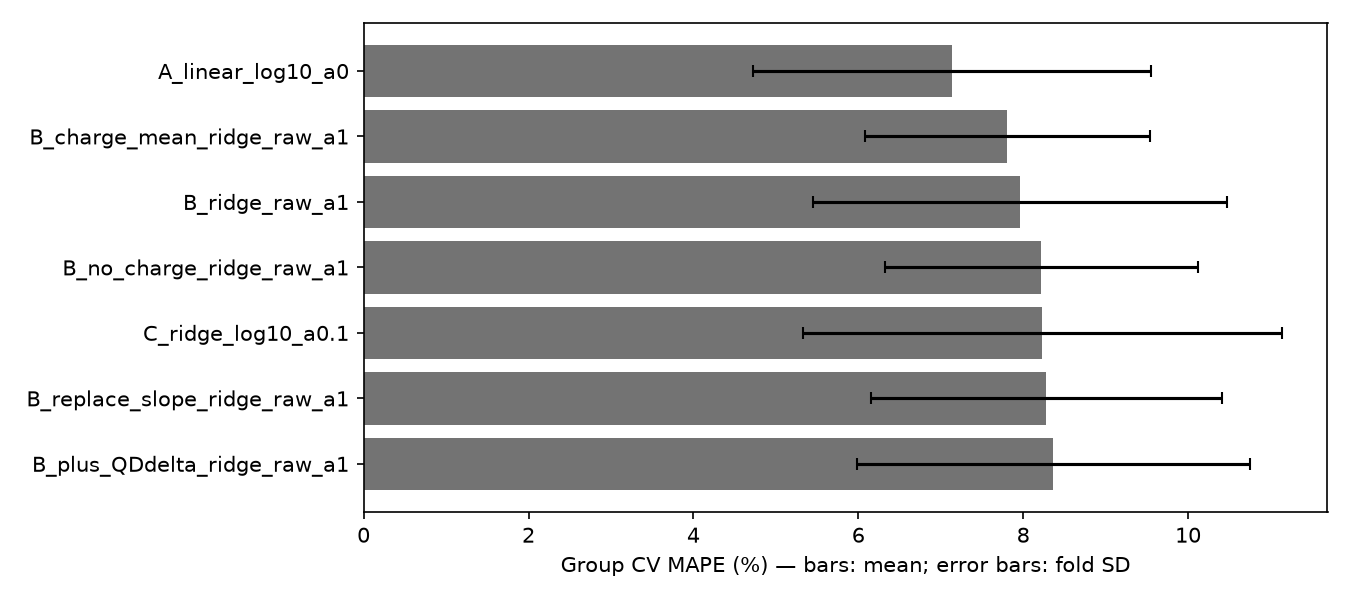

In [5]:
cv = pd.read_csv(RESULTS / 'cv_candidates.csv')
display(cv.sort_values('cv_mean_MAPE_pct').head(12))
selection = json.loads((RESULTS / 'model_selection.json').read_text())
display(pd.Series(selection))
display(Image(filename=str(RESULTS / 'figures/01_cv_comparison.png')))

## 6. 성능표와 Gap 이해하기

MAPE=100×mean(|예측-실제|/실제)이며 낮을수록 좋다. **Train은 학습 데이터 적합 오차가 아니라 개발 셀의 CV 평균**이다. 아래 Gap 행은 오류율 차이인 **%p**이며, 양수는 뒤 평가의 오차 증가로 정의했다.

| 구분 | MAPE (%) | 비고 |
| --- | --- | --- |
| Train (Batch 1 CV) | 7.201 | 5-fold 정책 그룹 CV; std=2.812%; 개발 셀만 사용 |
| Valid (Batch 1 Hold-out) | 13.144 | 모델 선택 후 1회 확인; 정책 그룹 분리 |
| Test (Batch 2) | 31.529 | 전체 B1 재학습 모델; 유효 라벨 39셀 |
| Gap (Train-Valid) | 5.943 | Valid - CV; 단위 %p; (+) 오차 증가 |
| Gap (Valid-Test) | 18.385 | B2 - Valid; 단위 %p; (+) 일반화 저하 가능성 |
| Gap (Target-Test) | 22.429 | B2 - 9.1; 단위 %p; 동일 조건 재현 아님 |
| Test (Batch 3) | 12.591 | 선택 사항; B2와 동일한 최종 모델; 유효 라벨 44셀 |
| Gap (Batch2-Batch3) | -18.939 | B3 - B2; 단위 %p; (+) B3 오차 증가 |
| Gap (Target-Test, Batch 3) | 3.491 | B3 - 9.1; 과제 비교 기준; 단위 %p |

| 평가 | MAE / 회 | RMSE / 회 | R² |
| --- | --- | --- | --- |
| B1 Hold-out | 123.485 | 151.029 | 0.362 |
| B2 | 155.588 | 169.556 | 0.402 |
| B3 | 157.504 | 258.899 | 0.304 |

- Train–Valid +5.943%p: 내부 선택 결과보다 Hold-out 오차가 크다. 작은 표본·그룹 구성·선택 편향과 과적합 가능성을 함께 고려하며 단독으로 원인을 확정하지 않는다.
- Valid–Test +18.385%p: B2 일반화 성능이 크게 저하됐다. 주요 원인 후보는 단수명 영역 부족과 피처–수명 관계의 배치 차이다.
- Target–Test +22.429%p: **논문 비교 목표 9.1%를 달성하지 못했다.** 데이터 배치 날짜, 연속 셀 연결·제외 규칙, 분할, 피처와 모델이 달라 동일 조건 논문 재현이라고 해석할 수 없다.
- B3–B2 -18.939%p: B3의 MAPE는 낮지만 B3 장수명 셀에는 큰 과소 예측이 있다. 평균 지표만으로 실제 운용 적합성을 판단하지 않는다. B3 목표 차이는 과제의 9.1% 비교 기준이며 원논문의 B3 고유 성능을 재현한 값이 아니다.

OOF 전체 셀을 한 번에 계산한 MAPE는 7.290%로, 과제 표의 fold 평균 7.201%와 다르다. fold 크기가 달라 가중치가 다르며 표에는 요구대로 fold 평균을 사용했다.

![실제 수명과 예측 수명](results/day2/figures/02_actual_vs_predicted.png)


,구분,MAPE (%),비고
0,Train (Batch 1 CV),7.200716,5-fold 정책 그룹 CV; std=2.812%; 개발 셀만 사용
1,Valid (Batch 1 Hold-out),13.143946,모델 선택 후 1회 확인; 정책 그룹 분리
2,Test (Batch 2),31.529071,전체 B1 재학습 모델; 유효 라벨 39셀
3,Gap (Train-Valid),5.943230,Valid - CV; 단위 %p; (+) 오차 증가
4,Gap (Valid-Test),18.385125,B2 - Valid; 단위 %p; (+) 일반화 저하 가능성
5,Gap (Target-Test),22.429071,B2 - 9.1; 단위 %p; 동일 조건 재현 아님
6,Test (Batch 3),12.590544,선택 사항; B2와 동일한 최종 모델; 유효 라벨 44셀
7,Gap (Batch2-Batch3),-18.938527,B3 - B2; 단위 %p; (+) B3 오차 증가
8,"Gap (Target-Test, Batch 3)",3.490544,B3 - 9.1; 과제 비교 기준; 단위 %p


,MAPE_pct,MAE_cycles,RMSE_cycles,R2
Hold-out B1,13.143946,123.485419,151.029271,0.362292
Test B2,31.529071,155.588452,169.556315,0.402395
Test B3,12.590544,157.504330,258.899374,0.303778
CV pooled OOF,7.290070,60.527044,75.479305,0.819355


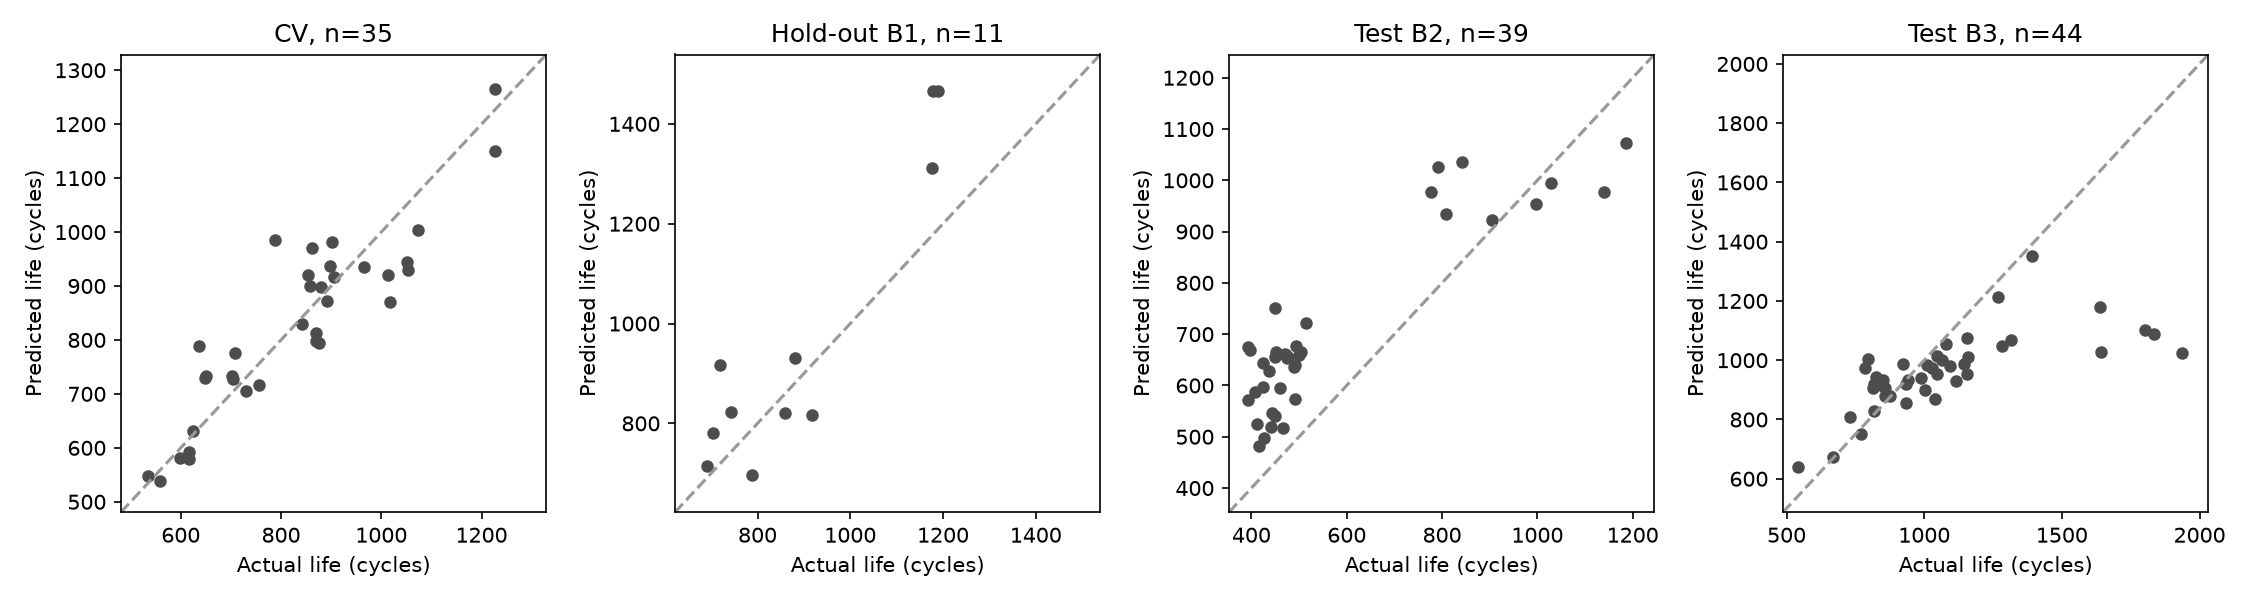

In [6]:
performance = pd.read_csv(RESULTS / 'model_performance.csv')
display(performance)
audit = json.loads((RESULTS / 'evaluation_audit.json').read_text())
display(pd.DataFrame(audit['metrics']).T)
display(Image(filename=str(RESULTS / 'figures/02_actual_vs_predicted.png')))

## 7. 틀린 예측을 직접 확인하기

| cell_id | policy | cycle_life | prediction | residual_cycles | APE_pct |
| --- | --- | --- | --- | --- | --- |
| b2c6 | 3.6C(9%)-5C | 393.000 | 674.575 | 281.575 | 71.647 |
| b2c15 | 3.6C(9%)-5C | 396.000 | 668.611 | 272.611 | 68.841 |
| b2c18 | 5.2C(50%)-4.25C | 449.000 | 751.241 | 302.241 | 67.314 |
| b3c38 | 5C(67%)-4C-newstructure | 1935.000 | 1025.773 | -909.227 | 46.988 |
| b3c7 | 4.8C(80%)-4.8C-newstructure | 1836.000 | 1089.217 | -746.783 | 40.674 |
| b3c45 | 4.8C(80%)-4.8C-newstructure | 1801.000 | 1103.104 | -697.896 | 38.750 |

B2에서 APE가 가장 큰 b2c6는 실제 393회인데 약 675회로 예측해 **71.647%** 오차가 났다. b2c15도 같은 `3.6C(9%)-5C` 정책이며, b2c18은 다른 정책에서 큰 오차를 보였다. 일부 정책과 단수명 구간에서 수명이 과대 예측되지만 정책 자체가 원인이라고 단정할 수 없다.

B3의 b3c38은 실제 1,935회인데 약 1,026회로 예측해 **909회 과소 예측**됐다. B1 최대 수명이 1,227회여서 이런 장수명 영역을 학습하지 못했다. `newstructure`의 Qdlin 측정 절차 차이도 원인 후보이며 현재 분산 피처만으로 해결됐다고 주장하지 않는다.

| stage | life_group | n | overprediction_n | MAPE_pct | MAE_cycles |
| --- | --- | --- | --- | --- | --- |
| Test B2 | <500 | 28 | 28 | 36.749 | 163.169 |
| Test B2 | 500–1000 | 8 | 7 | 21.695 | 148.684 |
| Test B2 | >1000 | 3 | 0 | 9.034 | 103.252 |
| Test B3 | 500–1000 | 21 | 16 | 8.842 | 70.431 |
| Test B3 | >1000 | 23 | 0 | 16.013 | 237.006 |

B2 단수명(<500) 28셀 **모두 과대 예측**, MAPE 36.749%다. B3 장수명(>1000) 23셀 **모두 과소 예측**이다. B1 dq_logvar 범위는 -5.015~-3.350이고 B2 11/39셀·B3 1/44셀이 이를 벗어난다. 그러나 최대 B2 오차 셀 b2c6는 범위 안에 있으므로 입력 범위 이탈만으로 실패를 설명할 수 없다. B1에서 배운 조건부 관계가 배치 간 그대로 유지되지 않았을 가능성을 추가 검증해야 한다.

`external_errors.csv`, `errors_by_policy.csv`, `errors_by_life_group.csv`, `feature_shift.csv`에 전체 결과가 있다. 후속 개선은 신규 독립 개발 데이터의 단수명/장수명 보강, 라벨 연결·검열 감사, 측정 절차 정합, 시간 가중 전류·곡선 피처 검증 순으로 진행한다. 이미 확인한 B2 점수에 맞춰 모델이나 삭제 규칙을 바꾼 결과를 새로운 test 성능으로 제시하지 않는다.

![외부 배치 잔차](results/day2/figures/03_external_residuals.png)


Batch 2: APE가 큰 셀


,cell_id,batch,policy,cycle_life,endpoint_quality_flag,prediction,residual_cycles,APE_pct,stage,candidate,fold,life_group,dq_logvar
0,b2c6,2,3.6C(9%)-5C,393.0,False,674.574572,281.574572,71.647474,Test B2,A_linear_raw_a0,NaN,<500,-3.530040
1,b2c15,2,3.6C(9%)-5C,396.0,False,668.611320,272.611320,68.841242,Test B2,A_linear_raw_a0,NaN,<500,-3.516252
2,b2c18,2,5.2C(50%)-4.25C,449.0,False,751.241434,302.241434,67.314351,Test B2,A_linear_raw_a0,NaN,<500,-3.707303
3,b2c2,2,5.2C(50%)-4.25C,424.0,False,644.389593,220.389593,51.978677,Test B2,A_linear_raw_a0,NaN,<500,-3.460248
4,b2c29,2,5.2C(58%)-4C,452.0,False,665.149673,213.149673,47.157007,Test B2,A_linear_raw_a0,NaN,<500,-3.508248


Batch 3: APE가 큰 셀


,cell_id,batch,policy,cycle_life,endpoint_quality_flag,prediction,residual_cycles,APE_pct,stage,candidate,fold,life_group,dq_logvar
5,b3c38,3,5C(67%)-4C-newstructure,1935.0,False,1025.773065,-909.226935,46.988472,Test B3,A_linear_raw_a0,NaN,>1000,-4.342053
10,b3c7,3,4.8C(80%)-4.8C-newstructure,1836.0,False,1089.216610,-746.783390,40.674477,Test B3,A_linear_raw_a0,NaN,>1000,-4.488742
15,b3c45,3,4.8C(80%)-4.8C-newstructure,1801.0,False,1103.103692,-697.896308,38.750489,Test B3,A_linear_raw_a0,NaN,>1000,-4.520851
19,b3c42,3,4.8C(80%)-4.8C-newstructure,1642.0,False,1027.564338,-614.435662,37.419955,Test B3,A_linear_raw_a0,NaN,>1000,-4.346195
27,b3c16,3,4.8C(80%)-4.8C-newstructure,1638.0,False,1178.213390,-459.786610,28.070001,Test B3,A_linear_raw_a0,NaN,>1000,-4.694513


,stage,life_group,n,overprediction_n,MAPE_pct,MAE_cycles,RMSE_cycles,R2
0,Test B2,<500,28,28,36.748969,163.168672,175.164493,-29.253684
1,Test B2,500–1000,8,7,21.695155,148.683743,166.474981,-0.039483
2,Test B2,>1000,3,0,9.033801,103.252286,116.046369,-2.100876
3,Test B3,500–1000,21,16,8.842436,70.430618,89.769414,0.147298
4,Test B3,>1000,23,0,16.012729,237.006416,347.665598,-0.482319


,batch,feature,B1_min,B1_max,external_min,external_max,outside_B1_n,missing_n
0,2,dq_logvar,-5.014861,-3.350338,-4.448585,-3.085882,11,0
1,3,dq_logvar,-5.014861,-3.350338,-5.098856,-3.451658,1,0


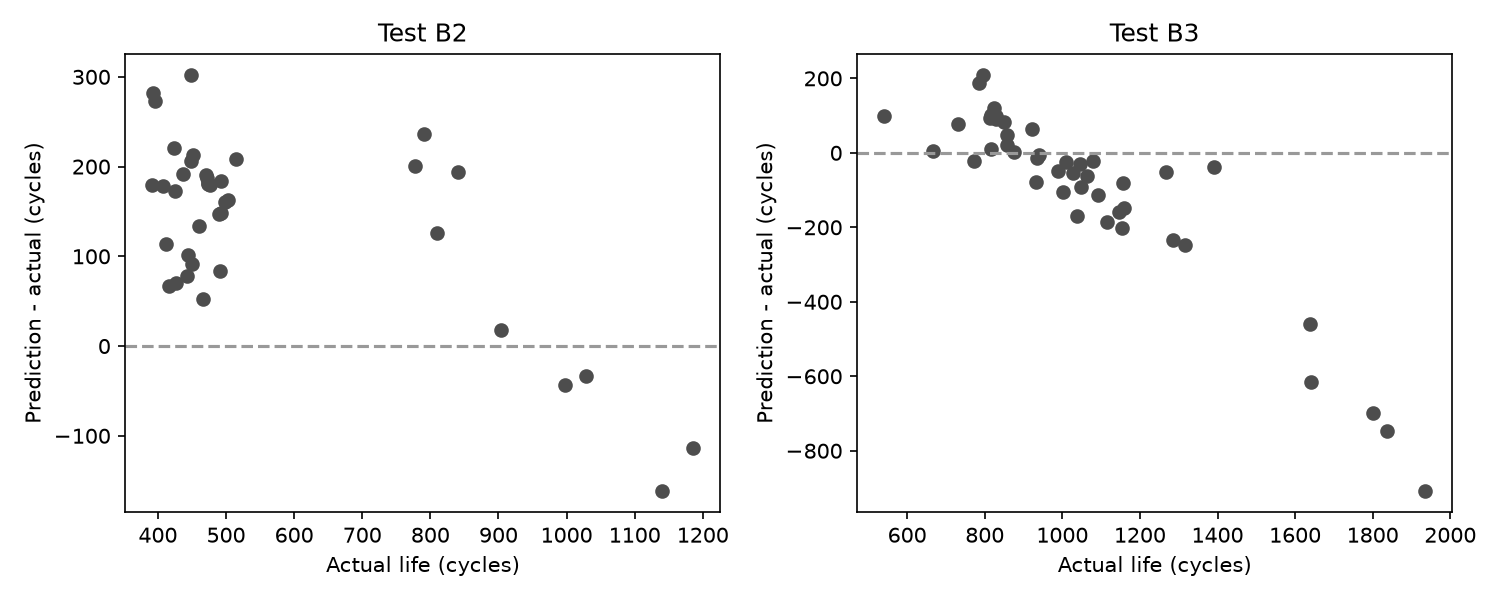

In [7]:
errors = pd.read_csv(RESULTS / 'external_errors.csv')
for batch in (2, 3):
    print(f'Batch {batch}: APE가 큰 셀')
    display(errors[errors.batch == batch].head(5))
display(pd.read_csv(RESULTS / 'errors_by_life_group.csv'))
display(pd.read_csv(RESULTS / 'feature_shift.csv'))
display(Image(filename=str(RESULTS / 'figures/03_external_residuals.png')))

## 8. 품질 후보 삭제가 답인지 확인하기

주 분석은 원본 B1 46셀을 유지한다. `endpoint_quality_flag`는 끝 QD>0.885Ah인 확인 후보이며 미완료/잘못된 라벨이 확정된 것은 아니다. 입력 피처나 배포 시 판별 규칙으로 사용하지 않는다.

고정 fold의 **학습 셀에서만** 후보를 제외한 보조 모델을 같은 35개 OOF 검증 셀로 평가했다. 원본 학습 CV 평균은 7.201%, 후보 제외 학습은 7.427%다. 원본과 검증 분모를 유지했으며, 이 결과로 최종 선택·B2/B3 모델을 변경하지 않았다.

검증 셀 중 품질 후보 포함/미포함 n은 7/28이다. 제외 학습 모델의 해당 MAPE는 4.297/8.360%이며 작은 집단의 기술 통계다. 최종 46셀 전체 학습과 보조 35셀 CV 실험의 학습 모집단을 구분한다. 종료 사유와 원저자 연속 셀 연결을 확인하기 전에는 일괄 삭제나 관측 길이 기반 라벨 수정이 적절하지 않다.


In [8]:
display(pd.read_csv(RESULTS / 'quality_sensitivity_folds.csv'))
display(pd.read_csv(RESULTS / 'quality_sensitivity_groups.csv'))
display(pd.DataFrame(json.loads((RESULTS / 'residual_diagnostics.json').read_text())))

,scenario,fold,train_original_n,train_used_n,valid_n,MAPE_pct,MAE_cycles,RMSE_cycles,R2
0,train_only_endpoint_exclusion,1,27,22,8,4.597687,36.707721,40.881428,0.976570
1,train_only_endpoint_exclusion,2,27,20,8,11.217882,83.125553,92.147743,0.126081
2,train_only_endpoint_exclusion,3,28,22,7,9.718791,88.286316,108.611146,-0.219483
3,train_only_endpoint_exclusion,4,29,24,6,6.550794,51.955664,58.942371,0.641437
4,train_only_endpoint_exclusion,5,29,24,6,5.048913,47.853531,65.401172,0.854084


,validation_endpoint_flag,n,MAPE_pct,MAE_cycles,RMSE_cycles,R2
0,False,28,8.35972,66.902199,83.162344,0.731067
1,True,7,4.29745,43.180574,48.897025,0.893693


,fold,n,rho_squared_dq_residual
0,1,8,0.333333
1,2,8,0.452381
2,3,7,0.214286
3,4,6,0.600000
4,5,6,-0.257143


## 9. ESS 해석과 제출 요건

ESS 운영에서 이런 모델은 초기 사용 이력으로 상대적 열화 위험을 선별하고, 점검 우선순위·예비 셀 확보·교체 예산 검토를 돕는 후보 도구다. 현재 모델은 Batch 2의 단수명 셀을 일관되게 과대 예측하므로 교체 시점을 자동 결정하는 근거로 사용할 수 없다. 과대 예측은 늦은 점검·교체로, 과소 예측은 불필요하게 이른 교체와 비용 증가로 이어질 수 있다.

실험실 단일 셀의 총 사이클 수를 예측했으며 현재 SOH, 팩 수명, 잔여 달력 시간이나 정확한 고장 날짜를 계산한 것이 아니다. 팩의 셀 편차·열관리·부하 프로파일·SOC 운용 구간·달력 열화·BMS 센서 품질을 추가로 반영해야 한다. 100사이클까지 관찰해야 한다는 적용 시점 제약도 있다.

배포 전에는 현장 BMS 데이터로 시간·사이트·팩 단위 외부 검증, 신규 배치에서의 보정과 불확실성 평가, 비용을 반영한 과대/과소 예측 평가가 필요하다. 모델을 업데이트하면 새 평가셋을 확보하고, 초기 피처 분포·결측률·현장 오차를 모니터링한다. 예측을 실제 SOH 측정·안전 기준·운영자의 검토와 함께 사용해야 한다.

### 모니터링·재학습 운영 계획

아래 주기와 수치는 **현장 검증 전의 제안 기준**이다. 이번 과제에서 효과를 입증하거나 자동화한 운영 규칙이 아니다. 현재 모델은 B2 목표 미달과 단수명 과대 예측 때문에 연구용 참고 단계이며, 실제 ESS 교체 결정을 자동 수행하지 않는다.

| 주기 | 확인 내용 | 기록 및 조치 |
| --- | --- | --- |
| 매주 | 초기 피처 결측률, 기준 개발 데이터 범위를 벗어난 셀 비율, 센서·프로토콜 변경 | 모델/데이터 버전별 기록. 이상 신호는 데이터·측정 절차를 먼저 감사 |
| 매월 | 새로 EOL이 확인된 셀의 MAPE·MAE, 단수명 과대 예측 및 장수명 과소 예측 | 신규 유효 라벨 30셀 이상일 때 평가 창을 구성. 부족하면 누적하고 성능 저하를 확정하지 않음 |
| 분기마다 | 새로운 라벨·대표성·검열 상태, 최근 오류와 재학습 필요성 | 후보 재학습 여부를 검토하며 기존 모델을 자동 교체하지 않음 |

재학습 검토 촉발 조건은 ① 주간 결측률>5% 또는 기준 범위 이탈 비율>10%가 2회 연속 발생, ② 새로운 현장 기준 성능보다 월간 MAPE가 5%p 이상 증가하는 평가 창이 2회 연속 발생, ③ 센서·곡선 측정 절차·셀 종류·충전 프로토콜이 변경되는 경우로 제안한다. 현장 기준 성능은 최초 독립 현장 검증에서 설정하며, B1 CV 7.201%나 논문 9.1%를 현장 정상값으로 가정하지 않는다. 기준 범위는 초기 승인 개발 데이터에서 고정하고 운영 데이터로 자동 갱신하지 않는다.

경보가 나면 박민규가 데이터·라벨 원인을 검토하고, 실제 배포 단계에서는 현장 운영 책임자가 사용 제한과 갱신을 승인하도록 한다. EOL 라벨은 늦게 확보되므로 입력 드리프트 경보와 성능 경보를 구분한다. 라벨 30셀은 실무 검토를 시작하기 위한 제안 최소량이며 통계적 신뢰성을 보장하지 않는다.

후보를 재학습할 때는 신규 개발 데이터와 시간·사이트·팩·정책 그룹을 분리한 **새 Hold-out**을 먼저 고정한다. 과제 B2/B3를 새 시험처럼 재사용하지 않는다. 새 모델 채택은 같은 새 검증 셀에서 기준 모델보다 MAPE가 낮고 단수명 과대 예측 위험이 악화되지 않으며, 충분한 표본·오차 불확실성·현장 BMS 검증을 운영 책임자가 확인한 경우에만 검토한다. 개선을 확인하지 못하면 기존 연구 버전을 유지하고 적용 범위를 제한한다. 모델·데이터·평가 날짜와 승인 사유를 기록해 이전 버전으로 되돌릴 수 있게 한다.


공개 GitHub 링크와 Slack 제출은 별도로 완료해야 합니다. 요구사항 대조와 보수적 자체 채점은 `DAY2-Requirements-Check.md`, `DAY2-Rubric-Review.md`에 있습니다.

In [9]:
display(pd.DataFrame({'passed_check': verification['checks']}))
assert verification['status'] == 'PASS'
assert len(run_result['predictions']) == 129
print('모델·성능 재현 검증 완료. 목표 9.1% 미달과 공개 저장소/Slack 미제출을 구분합니다.')

,passed_check
0,139셀 원본·46/39/44 유효 라벨·입력 해시 확인
1,Hold-out 및 5개 fold의 셀·정책 중복 없음; OOF 1회씩
2,39개 후보 및 고정 1-SE 선택 규칙 재검증
3,외부 라벨·미래 정보 변경에 개발 입력 불변; 모든 후보 피처 허용 목록 확인
4,결측 보완 통계는 fold train 중앙값; predict가 전처리 통계 변경하지 않음
5,로그 타깃 역변환 후 원 사이클 단위 평가 확인
6,B1 전체 46셀 재학습 및 저장 모델의 B2/B3 예측 재현
7,129개 예측의 모집단·fold 평균/표준편차·MAPE 및 Gap 산식 확인
8,끝 용량 후보 민감도도 원본과 같은 35개 검증 셀로 평가


모델·성능 재현 검증 완료. 목표 9.1% 미달과 공개 저장소/Slack 미제출을 구분합니다.


## 참고문헌

- [DS Mini Project: Task·Deliverables·평가 항목](https://actually-war-1ea.notion.site/DS-Mini-Project-32d7f4c8669380338a27f90c471c1fcb)
- [DS Course Wrap-up](https://actually-war-1ea.notion.site/DS-Course-Wrap-up-27f7f4c866938053a154c817021f774f)
- [Severson et al. (2019), Nature Energy 4, 383–391](https://www.nature.com/articles/s41560-019-0356-8)
- [논문 저자 데이터 처리·모델 코드](https://github.com/rdbraatz/data-driven-prediction-of-battery-cycle-life-before-capacity-degradation)
- [Kaggle 배포본](https://www.kaggle.com/datasets/itshpark/data-driven-prediction-of-battery-cycle)
